In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from google.colab import drive

# Conectando ao Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
path_homicidios = '/content/drive/MyDrive/PIII - Análise de Crimes/Bases de dados/CRIMES CONTRA A VIDA/ANUÁRIO DE SEGURANÇA 2025/HISTÓRICO DE HOMÍCIDOS DOLOSOS POR MUNICÍPIO.csv'
path_roubos = '/content/drive/MyDrive/PIII - Análise de Crimes/Bases de dados/CRIMES CONTRA O PATRIMÔNIO/DADOS ABERTOS ES/roubos_2024.csv'


def ler_base(caminho):
    try:
        return pd.read_csv(caminho, sep=';', encoding='latin1', on_bad_lines='skip', engine='python')
    except:
        return pd.read_csv(caminho, sep=',', encoding='utf-8', on_bad_lines='skip', engine='python')

# Salvando nas variáveis
df_homicidios = ler_base(path_homicidios)
df_roubos = ler_base(path_roubos)

print("✅ Bases carregadas com sucesso!")

✅ Bases carregadas com sucesso!


In [3]:
print("--- COLUNAS HOMICÍDIOS ---")
if isinstance(df_homicidios, pd.DataFrame): print(df_homicidios.columns.tolist())

print("\n--- COLUNAS ROUBOS ---")
if isinstance(df_roubos, pd.DataFrame): print(df_roubos.columns.tolist())

display(df_homicidios.head(2))

--- COLUNAS HOMICÍDIOS ---
['TABELA 02,ÍNDICE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,']

--- COLUNAS ROUBOS ---
['ï»¿NÂº OCORRÃ\x8aNCIA', 'DATA DO FATO', 'HORA DO FATO', 'GRUPO DE INCIDENTE', 'TIPO DE INCIDENTE', 'UF', 'MUNICÃ\x8dPIO', 'BAIRRO', 'LOGRADOURO', 'TIPO DE LOCAL']


,"TABELA 02,ÍNDICE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,"
0,Série Histórica de Homicídios Dolosos por Muni...
1,"Municípios - 1996 - 2024,,,,,,,,,,,,,,,,,,,,,,..."


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pandas as pd

# 1. Renomeando as colunas para limpar aqueles caracteres estranhos
df_roubos.columns = ['NUM_OCORRENCIA', 'DATA', 'HORA', 'GRUPO', 'TIPO', 'UF', 'MUNICIPIO', 'BAIRRO', 'LOGRADOURO', 'TIPO_LOCAL']

# 2. Limpando a base: removendo nulos e arrumando a data
df_roubos = df_roubos.dropna(subset=['MUNICIPIO', 'DATA'])
df_roubos['DATA'] = pd.to_datetime(df_roubos['DATA'], errors='coerce', dayfirst=True)

print("✅ Base limpa com sucesso! Total de registros válidos:", len(df_roubos))

✅ Base limpa com sucesso! Total de registros válidos: 13506


In [5]:
# 3. Preparando os dados para o Teste T
# Pegando as duas cidades com mais roubos no ES automaticamente
top_cidades = df_roubos['MUNICIPIO'].value_counts().head(2).index.tolist()
cidade_A = top_cidades[0]
cidade_B = top_cidades[1]

# Agrupando a quantidade de roubos por DIA para cada cidade
diario_A = df_roubos[df_roubos['MUNICIPIO'] == cidade_A].groupby('DATA').size()
diario_B = df_roubos[df_roubos['MUNICIPIO'] == cidade_B].groupby('DATA').size()

print(f"📍 Cidades selecionadas para o Teste Estatístico: {cidade_A} e {cidade_B}")

📍 Cidades selecionadas para o Teste Estatístico: SERRA e VILA VELHA


In [6]:
# 4. APLICAÇÃO DO TESTE T
# Calculando o valor de t e o Valor-P
t_stat, p_valor = stats.ttest_ind(diario_A, diario_B, equal_var=False)

print("="*60)
print(" 📊 RESULTADO DO TESTE ESTATÍSTICO (TESTE T) 📊")
print("="*60)
print(f"Hipótese Nula (H0): A média diária de roubos em {cidade_A} é IGUAL à de {cidade_B}.")
print(f"Hipótese Alternativa (H1): As médias diárias são diferentes.")
print("-" * 60)
print(f"Média {cidade_A}: {diario_A.mean():.2f} roubos por dia")
print(f"Média {cidade_B}: {diario_B.mean():.2f} roubos por dia")
print(f"Valor T: {t_stat:.2f}")
print(f"Valor-P: {p_valor:.4f}")
print("-" * 60)

if p_valor < 0.05:
    print(f"CONCLUSÃO: Como o valor-p ({p_valor:.4f}) é menor que 0,05, REJEITAMOS H0.")
    print(f"Há uma diferença estatisticamente significativa entre {cidade_A} e {cidade_B}.")
else:
    print(f"CONCLUSÃO: Como o valor-p ({p_valor:.4f}) é maior que 0,05, ACEITAMOS H0.")
    print(f"As médias de roubos são estatisticamente semelhantes.")

 📊 RESULTADO DO TESTE ESTATÍSTICO (TESTE T) 📊
Hipótese Nula (H0): A média diária de roubos em SERRA é IGUAL à de VILA VELHA.
Hipótese Alternativa (H1): As médias diárias são diferentes.
------------------------------------------------------------
Média SERRA: 9.56 roubos por dia
Média VILA VELHA: 7.48 roubos por dia
Valor T: 7.21
Valor-P: 0.0000
------------------------------------------------------------
CONCLUSÃO: Como o valor-p (0.0000) é menor que 0,05, REJEITAMOS H0.
Há uma diferença estatisticamente significativa entre SERRA e VILA VELHA.


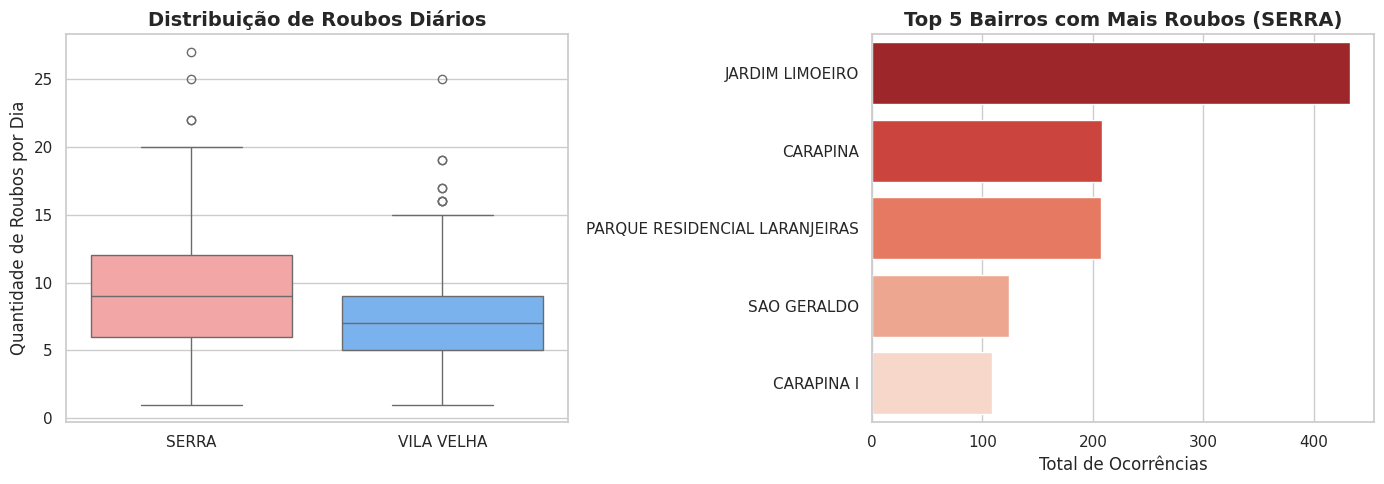

In [7]:
# 5. GERANDO O PROTÓTIPO VISUAL (CORRIGIDO)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Criando um DataFrame temporário para o Seaborn entender as cores perfeitamente
df_box = pd.DataFrame({
    'Cidade': [cidade_A]*len(diario_A) + [cidade_B]*len(diario_B),
    'Roubos': list(diario_A) + list(diario_B)
})

# Gráfico 1: Boxplot comparando a distribuição diária
sns.boxplot(data=df_box, x='Cidade', y='Roubos', ax=axes[0], hue='Cidade', palette=['#FF9999', '#66B2FF'], legend=False)
axes[0].set_title('Distribuição de Roubos Diários', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Quantidade de Roubos por Dia')
axes[0].set_xlabel('')

# Gráfico 2: Top 5 Bairros mais perigosos na Cidade A
top_bairros = df_roubos[df_roubos['MUNICIPIO'] == cidade_A]['BAIRRO'].value_counts().head(5)
sns.barplot(x=top_bairros.values, y=top_bairros.index, ax=axes[1], hue=top_bairros.index, palette='Reds_r', legend=False)
axes[1].set_title(f'Top 5 Bairros com Mais Roubos ({cidade_A})', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Total de Ocorrências')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

/tmp/ipykernel_518/1417235638.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_cidade_a['HORA_INT'] = pd.to_datetime(df_cidade_a['HORA'], errors='coerce').dt.hour


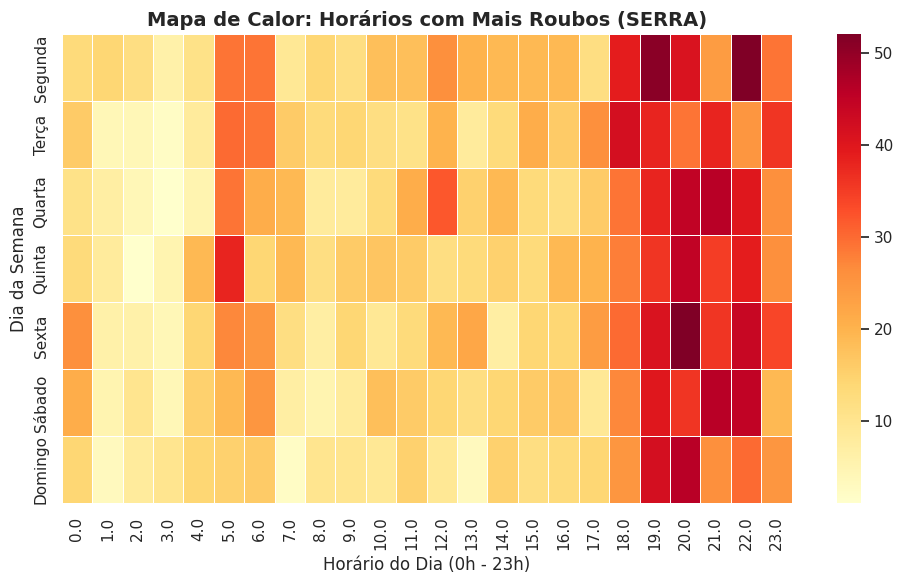

In [8]:
# 6. BÔNUS: MAPA DE CALOR (CORRIGIDO)
fig, ax = plt.subplots(figsize=(10, 6))

# Preparando os dados
df_cidade_a = df_roubos[df_roubos['MUNICIPIO'] == cidade_A].copy()

# CORREÇÃO 1: Extração de hora mais robusta (ignora formatações ruins e pega só a hora)
df_cidade_a['HORA_INT'] = pd.to_datetime(df_cidade_a['HORA'], errors='coerce').dt.hour

# Tirando os registros sem hora para não quebrar a matriz
df_cidade_a = df_cidade_a.dropna(subset=['HORA_INT'])

df_cidade_a['DIA_SEMANA'] = df_cidade_a['DATA'].dt.day_name()

# Traduzindo e ordenando os dias
dias_ordem = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dias_pt = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']
df_cidade_a['DIA_SEMANA'] = pd.Categorical(df_cidade_a['DIA_SEMANA'], categories=dias_ordem, ordered=True)

# CORREÇÃO 2: "observed=False" resolve o aviso, e a matriz cria a estrutura certinha
heatmap_data = df_cidade_a.groupby(['DIA_SEMANA', 'HORA_INT'], observed=False).size().unstack(fill_value=0)

if not heatmap_data.empty:
    heatmap_data.index = dias_pt
    # Plotando o Heatmap
    sns.heatmap(heatmap_data, cmap="YlOrRd", linewidths=.5, ax=ax)
    ax.set_title(f'Mapa de Calor: Horários com Mais Roubos ({cidade_A})', fontsize=14, fontweight='bold')
    ax.set_xlabel('Horário do Dia (0h - 23h)')
    ax.set_ylabel('Dia da Semana')

    plt.tight_layout()
    plt.show()
else:
    print("❌ Não foi possível gerar o Mapa de Calor: os dados da coluna de HORA estão ausentes ou num formato muito diferente.")

/tmp/ipykernel_518/980127517.py:32: UserWarning: Glyph 154 (\x9a) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_518/980127517.py:32: UserWarning: Glyph 141 (\x8d) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_518/980127517.py:32: UserWarning: Glyph 137 (\x89) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 154 (\x9a) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 141 (\x8d) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 137 (\x89) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


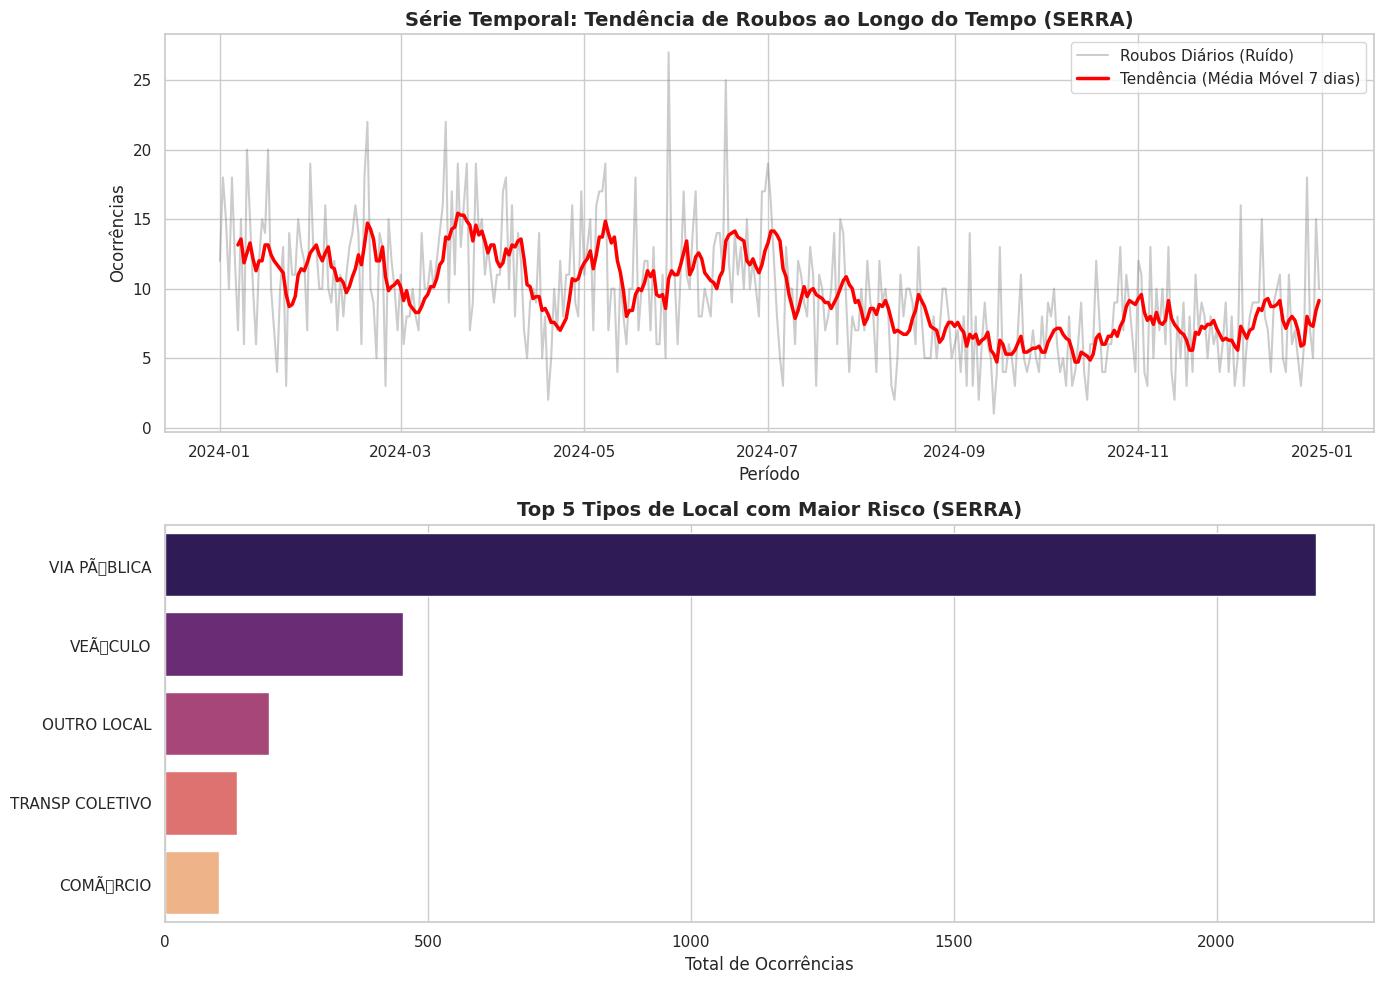

In [9]:
# 7. SÉRIES TEMPORAIS E ANÁLISE DE LOCAL
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# --- Gráfico A: Evolução Temporal com Média Móvel ---
# Preparando os dados da Cidade A
diario_A_df = diario_A.reset_index(name='Roubos').sort_values('DATA')
# Calculando a Média Móvel de 7 dias para suavizar o ruído
diario_A_df['Media_Movel_7d'] = diario_A_df['Roubos'].rolling(window=7).mean()

# Plotando os dados diários (ruído) e a tendência (média móvel)
sns.lineplot(data=diario_A_df, x='DATA', y='Roubos', ax=axes[0], color='gray', alpha=0.4, label='Roubos Diários (Ruído)')
sns.lineplot(data=diario_A_df, x='DATA', y='Media_Movel_7d', ax=axes[0], color='red', linewidth=2.5, label='Tendência (Média Móvel 7 dias)')

axes[0].set_title(f'Série Temporal: Tendência de Roubos ao Longo do Tempo ({cidade_A})', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Ocorrências')
axes[0].set_xlabel('Período')
axes[0].legend()

# --- Gráfico B: Incidência por Tipo de Local ---
top_locais = df_cidade_a['TIPO_LOCAL'].value_counts().head(5)

# Plotando gráfico de barras horizontais
sns.barplot(x=top_locais.values, y=top_locais.index, ax=axes[1], hue=top_locais.index, palette='magma', legend=False)
axes[1].set_title(f'Top 5 Tipos de Local com Maior Risco ({cidade_A})', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Total de Ocorrências')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()